# Part 2(c)

In [2]:
#1.Exclude cancelled flights
#2.Select key features 
#3.Convert data types for modeling
#4.Split data into training (40%) and testing (60%) sets
#5.Process features by one-hot encoding categorical variable
#6.Train a logistic regression model for flight diversion prediction
#7.Analyze coefficients yearly to see feature impacts over time
#8.Visualize results with a trend plot of coefficients

In [4]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [6]:
# Load data and import it into data frame
airports_df = pd.read_csv('airports.csv')
carriers_df = pd.read_csv('carriers.csv')
planes_df = pd.read_csv('plane-data.csv')
ontime_df = pd.concat(
            [pd.read_csv(f"{year}.csv/{year}.csv") for year in range(2004, 2009)]
            ,ignore_index=True
            )

## Convert cancelled flights to NA and remove them

In [10]:
ontime_df['Cancelled'] = ontime_df['Cancelled'].replace(1, np.nan)
ontime_df = ontime_df.dropna(subset=['Cancelled'])

## Select relevant features

In [13]:
part_c_df = ontime_df[['Year', 'DayOfWeek', 'CRSDepTime', 'CRSArrTime', 'UniqueCarrier', 'Distance', 'Diverted']].copy()

## Convert data types for modeling

In [16]:
part_c_df['Year'] = part_c_df['Year'].astype(str)  # Keep as string for visualization
part_c_df['DayOfWeek'] = part_c_df['DayOfWeek'].astype(str)
part_c_df['UniqueCarrier'] = part_c_df['UniqueCarrier'].astype(str)
part_c_df['Diverted'] = part_c_df['Diverted'].astype(int)  # Ensure binary target


## Split data into training (40%) and testing (60%) sets

In [19]:
np.random.seed(123)
train_set, test_set = train_test_split(part_c_df, test_size=0.6, random_state=123)


## Split Data into Features (X) and Target (y)

In [22]:
X_train = train_set[['DayOfWeek', 'CRSDepTime', 'CRSArrTime', 'UniqueCarrier', 'Distance']]
y_train = train_set['Diverted']

X_test = test_set[['DayOfWeek', 'CRSDepTime', 'CRSArrTime', 'UniqueCarrier', 'Distance']]
y_test = test_set['Diverted']

## One-hot encode categorical variables

In [25]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

## Model Training

In [28]:
lr_model = LogisticRegression(max_iter=500) # Create a logistic regression classifier
lr_model.fit(X_train, y_train) # Train mode

LogisticRegression(max_iter=500)

## Evaluate the model’s performance

In [31]:
y_pred = lr_model.predict(X_test) # Predict on test set

accuracy = accuracy_score(y_test, y_pred)
classification_error = 1 - accuracy # Compute classification error

classification_error


0.0021785610837353753

## Yearly Coefficient Analysis

In [34]:
# 1.Create empty list to store coefficients
# 2.Loop through each year 
# 3.Standardize features (mean=0, std=1)
# 4.Fit logistic regression model to the year’s data
# 5.Extract coefficients for each feature
# 6.Convert results into one data frame

In [42]:
coef_data = [] 

for yr in part_c_df["Year"].unique():
  
    year_data = part_c_df[part_c_df["Year"] == yr] # Subset data for the specific year

    X_year = year_data[["CRSDepTime", "CRSArrTime", "Distance"]] # Select only the features shown in R
    y_year = year_data["Diverted"]

    X_year = (X_year - X_year.mean()) / X_year.std() # Standardize features to match R’s scale

    model = LogisticRegression(max_iter=500) 
    model.fit(X_year, y_year) # Fit logistic regression model

    for feature, coef in zip(X_year.columns, model.coef_[0]): # Extract coefficients for each feature
        coef_data.append({"Year": yr, "Feature": feature, "Coefficient": coef})
        
coef_df = pd.DataFrame(coef_data) # Convert to DataFrame

## Plot how feature importance (coefficients) changes across years 

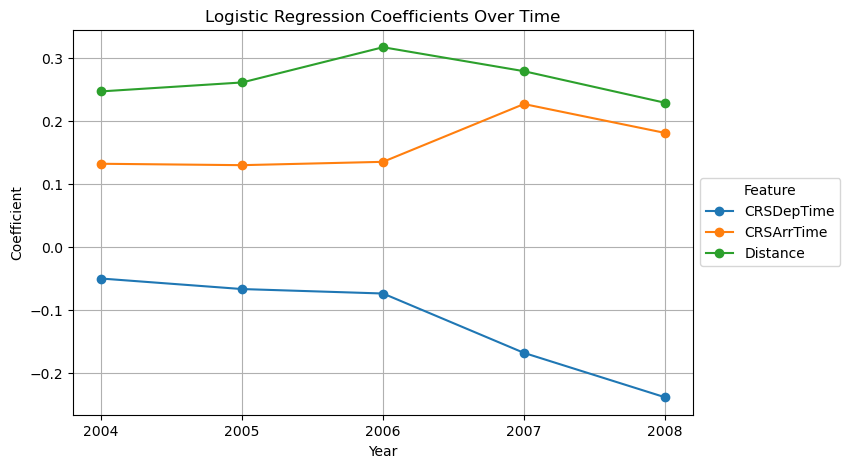

In [45]:
plt.figure(figsize=(8, 5))
for feature in coef_df["Feature"].unique():
    subset = coef_df[coef_df["Feature"] == feature]
    plt.plot(subset["Year"], subset["Coefficient"], marker="o", label=feature)

plt.title("Logistic Regression Coefficients Over Time")
plt.xlabel("Year")
plt.ylabel("Coefficient")
plt.legend(title="Feature", loc="center left", bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()